# NB03 — DINOv2-Small backbone

**Purpose**: Test whether a self-supervised ViT backbone improves over the ResNet-50
baseline (NB02). Structure and metrics are identical to NB02 so results are directly
comparable in NB04.

**Key differences from NB02**:
- Backbone: `dinov2_vits14` (ViT-Small, patch size 14, feature dim 384)
- Input size: 518×518 px (= 37×37 patches; 336×336 was the alternative — see §3)
- Features cached to `features/dinov2_vits14/`
- Optional backbone fine-tuning section (last 2 blocks, lr=1e-5, default **OFF**)
- Attention map visualisation of CLS-to-patch attention

**Inputs**:
- `data/processed/bt_scores_augmented.csv`
- `outputs/split_assignment.csv`
- Reprojected JPEGs at `REPRO_ROOT / {intersection_id} / leg_{bearing:.0f}.jpeg`

**Outputs**:
- `features/dinov2_vits14/{sample_id}.pt` — cached feature vectors
- `outputs/dinov2_vits14_best.pt` — best frozen-head checkpoint
- `outputs/dinov2_vits14_finetuned_best.pt` — fine-tuned checkpoint (if enabled)
- `outputs/dinov2_vits14_metrics.json` — validation metrics for NB04
- `outputs/nb03_training_curve.png`
- `outputs/nb03_attention_maps.png`
- `outputs/nb03_residual_plot.png`

---

**Imports**

In [1]:
import json
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from scipy import stats
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

warnings.filterwarnings("ignore", category=UserWarning)

**Configuration** — Flags and hyperparameters. Identical flags to NB02 so you can
run the same configuration and compare fairly.

| Hyperparameter | Value | Rationale |
|---|---|---|
| `IMAGE_SIZE` | 518 | 518 = 37×14 — maximum spatial resolution for patch_size=14; chosen over 336 (24×14) to preserve street-level detail |
| `LEARNING_RATE` | 1e-3 | Same as NB02 for fair comparison |
| `WEIGHT_DECAY` | 1e-2 | L2 regularisation — critical with ~64 training intersections |
| `FINETUNE_LR` | 1e-5 | Small lr for backbone blocks; avoids destroying pretrained representations |
| `FINETUNE_PATIENCE` | 5 | Short patience — fine-tuning on small N overfits quickly |

In [2]:
# ---------------------------------------------------------------------------
# EXPERIMENT FLAGS — mirror NB02 flags for a fair comparison
# ---------------------------------------------------------------------------
USE_ORIGINALS_ONLY = True    # train on 68 originals only (no augmented copies)
NORMALIZE_FEATURES = True    # L2-normalise feature vectors before training
HEAD_TYPE          = "linear" # "linear" or "mlp" — linear worked best in NB02
WEIGHT_DECAY       = 1e-2    # L2 regularisation for Adam

# Fine-tuning: unfreeze the last 2 DINOv2 transformer blocks and train end-to-end.
# Keep False until the frozen-head run is complete and validated.
FINETUNE_BACKBONE  = False

# ---------------------------------------------------------------------------
# BACKBONE
# ---------------------------------------------------------------------------
BACKBONE_NAME = "dinov2_vits14"
FEATURE_DIM   = 384    # DINOv2-Small CLS token output dimension

# Input image size for DINOv2 with patch_size=14.
# 518 = 37 × 14 → 37×37 = 1369 patches (max spatial resolution).
# Alternative: 336 = 24 × 14 → 576 patches (faster, less detail).
# Chosen 518 to preserve lane widths, markings, and road geometry.
IMAGE_SIZE = 518

# ---------------------------------------------------------------------------
# REGRESSION HEAD HYPERPARAMETERS (frozen-head run)
# ---------------------------------------------------------------------------
HIDDEN_DIM    = 128
DROPOUT       = 0.3
LEARNING_RATE = 1e-3
BATCH_SIZE    = 32
MAX_EPOCHS    = 200
PATIENCE      = 20

# ---------------------------------------------------------------------------
# FINE-TUNING HYPERPARAMETERS (only used when FINETUNE_BACKBONE=True)
# ---------------------------------------------------------------------------
FINETUNE_LR       = 1e-5   # backbone lr; head keeps LEARNING_RATE
FINETUNE_PATIENCE = 5      # short patience — fine-tuning overfits quickly at small N
FINETUNE_EPOCHS   = 50
N_BLOCKS_UNFREEZE = 2      # number of last transformer blocks to unfreeze

# ---------------------------------------------------------------------------
# PATHS
# ---------------------------------------------------------------------------
CV_ROOT      = Path("..")
REPRO_ROOT   = Path(r"D:\rotterdam_aiis_2025\vault-production\vault_v1\reprojected_directional_fov90_dist20_new")

BT_SCORES_CSV  = CV_ROOT / "data" / "processed" / "bt_scores_augmented.csv"
SPLIT_CSV      = CV_ROOT / "outputs" / "split_assignment.csv"
FEATURES_DIR   = CV_ROOT / "features" / BACKBONE_NAME
OUTPUTS_DIR    = CV_ROOT / "outputs"
CHECKPOINT     = OUTPUTS_DIR / f"{BACKBONE_NAME}_best.pt"
FT_CHECKPOINT  = OUTPUTS_DIR / f"{BACKBONE_NAME}_finetuned_best.pt"
METRICS_JSON   = OUTPUTS_DIR / f"{BACKBONE_NAME}_metrics.json"

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"=== Experiment configuration ===")
print(f"Backbone           : {BACKBONE_NAME}  (feature_dim={FEATURE_DIM})")
print(f"Image size         : {IMAGE_SIZE}×{IMAGE_SIZE}  ({IMAGE_SIZE//14}×{IMAGE_SIZE//14} patches)")
print(f"USE_ORIGINALS_ONLY : {USE_ORIGINALS_ONLY}")
print(f"NORMALIZE_FEATURES : {NORMALIZE_FEATURES}")
print(f"HEAD_TYPE          : {HEAD_TYPE}")
print(f"WEIGHT_DECAY       : {WEIGHT_DECAY}")
print(f"FINETUNE_BACKBONE  : {FINETUNE_BACKBONE}")
print(f"Device             : {device}")
print(f"REPRO_ROOT exists  : {REPRO_ROOT.exists()}")

=== Experiment configuration ===
Backbone           : dinov2_vits14  (feature_dim=384)
Image size         : 518×518  (37×37 patches)
USE_ORIGINALS_ONLY : True
NORMALIZE_FEATURES : True
HEAD_TYPE          : linear
WEIGHT_DECAY       : 0.01
FINETUNE_BACKBONE  : False
Device             : cpu
REPRO_ROOT exists  : True


## 1. Load data

Identical to NB02 — same split, same filtering of no-bearing rows.

In [3]:
bt    = pd.read_csv(BT_SCORES_CSV)
split = pd.read_csv(SPLIT_CSV)

df = bt.merge(split[["sample_id", "cv_split"]], on="sample_id", how="left")

# Drop rows whose leg_bearing is NaN — no photo path can be constructed
no_bearing = df["leg_bearing"].isna()
if no_bearing.any():
    n   = no_bearing.sum()
    ids = df.loc[no_bearing & ~df["is_augmented"], "intersection_id"].tolist()
    print(f"WARNING: dropping {n} rows with missing leg_bearing (intersection_ids: {ids})")
    df  = df[~no_bearing].copy()

train_df = df[df["cv_split"] == "train"].reset_index(drop=True)
val_df   = df[df["cv_split"] == "val"].reset_index(drop=True)

if USE_ORIGINALS_ONLY:
    train_df = train_df[~train_df["is_augmented"]].reset_index(drop=True)
    print("USE_ORIGINALS_ONLY=True — keeping original training samples only.")

print(f"Train : {len(train_df)}  (originals: {(~train_df['is_augmented']).sum()}, augmented: {train_df['is_augmented'].sum()})")
print(f"Val   : {len(val_df)}")

USE_ORIGINALS_ONLY=True — keeping original training samples only.
Train : 64  (originals: 64, augmented: 0)
Val   : 16


## 2. Transforms and dataset

DINOv2 requires inputs whose spatial dimensions are multiples of the patch size (14).
Training transform: resize to 560×560 then RandomCrop to 518×518 (mirrors the
NB02 pattern of 256→224 but scaled for patch_size=14). Validation: direct resize
to 518×518. No vertical flips — road/sky orientation is semantically meaningful.

In [4]:
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

# Resize to IMAGE_SIZE + margin then random crop to IMAGE_SIZE.
# The +42 margin (~8%) matches the 256→224 ratio used in NB02.
_RESIZE = IMAGE_SIZE + 42

train_transform = transforms.Compose([
    transforms.Resize((_RESIZE, _RESIZE)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=_MEAN, std=_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=_MEAN, std=_STD),
])


class IntersectionDataset(Dataset):
    """Loads reprojected JPEGs from disk with per-sample seeded augmentation.

    Training samples: random transform seeded with aug_seed (reproducible).
    Val samples: deterministic val_transform.
    """

    def __init__(self, df, repro_root, train_transform, val_transform):
        self.df              = df.reset_index(drop=True)
        self.repro_root      = Path(repro_root)
        self.train_transform = train_transform
        self.val_transform   = val_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        iid      = int(row["intersection_id"])
        bearing  = float(row["leg_bearing"]) % 360
        aug_seed = int(row["aug_seed"])
        is_val   = row["cv_split"] == "val"

        path = self.repro_root / str(iid) / f"leg_{bearing:.0f}.jpeg"
        img  = Image.open(path).convert("RGB")

        if is_val:
            img_tensor = self.val_transform(img)
        else:
            random.seed(aug_seed)
            torch.manual_seed(aug_seed)
            img_tensor = self.train_transform(img)

        return img_tensor, str(row["sample_id"]), float(row["bt_score"])


print(f"Train transform : {len(train_transform.transforms)} steps (input {_RESIZE}→{IMAGE_SIZE})")
print(f"Val transform   : {len(val_transform.transforms)} steps (input {IMAGE_SIZE})")

Train transform : 7 steps (input 560→518)
Val transform   : 3 steps (input 518)


## 3. Feature extraction (DINOv2-Small, frozen)

Load `dinov2_vits14` via `torch.hub`. First load downloads ~85 MB to
`~/.cache/torch/hub/`; subsequent runs use the local cache.

The model's forward pass returns the CLS token embedding (384-dim) when called
directly — no head replacement needed, unlike ResNet-50.

In [5]:
# torch.hub downloads the model on first call; subsequent calls use local cache
backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14", verbose=False)

# Freeze all backbone parameters — only the regression head is trained
for param in backbone.parameters():
    param.requires_grad = False
backbone.eval()
backbone.to(device)

n_params = sum(p.numel() for p in backbone.parameters())
print(f"DINOv2-Small loaded : {n_params/1e6:.1f}M params (all frozen)")
print(f"Patch size          : 14 px  →  {IMAGE_SIZE//14}×{IMAGE_SIZE//14} patches per image")
print(f"CLS feature dim     : {FEATURE_DIM}")

DINOv2-Small loaded : 22.1M params (all frozen)
Patch size          : 14 px  →  37×37 patches per image
CLS feature dim     : 384


In [6]:
all_df = pd.concat([train_df, val_df], ignore_index=True)
all_ds = IntersectionDataset(all_df, REPRO_ROOT, train_transform, val_transform)

already_cached = sum(1 for _, row in all_df.iterrows()
                     if (FEATURES_DIR / f"{row['sample_id']}.pt").exists())
print(f"Total samples    : {len(all_ds)}")
print(f"Already cached   : {already_cached}")
print(f"To extract       : {len(all_ds) - already_cached}")

Total samples    : 80
Already cached   : 0
To extract       : 80


In [7]:
@torch.no_grad()
def extract_and_cache(dataset, df, backbone, features_dir, device):
    """Run each image through the frozen backbone and cache the CLS feature vector."""
    backbone.eval()
    skipped   = 0
    extracted = 0
    errors    = []

    for idx in range(len(dataset)):
        sample_id  = df.iloc[idx]["sample_id"]
        cache_path = features_dir / f"{sample_id}.pt"

        if cache_path.exists():
            skipped += 1
            continue

        try:
            img_tensor, _, _ = dataset[idx]
            # DINOv2 forward returns the CLS token directly (384-dim)
            feat = backbone(img_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()
            torch.save(feat, cache_path)
            extracted += 1
        except Exception as e:
            errors.append((sample_id, str(e)))

        if (skipped + extracted) % 20 == 0 and (skipped + extracted) > 0:
            print(f"  {skipped + extracted}/{len(dataset)} ...", flush=True)

    print(f"Done. Reused: {skipped}  |  Extracted: {extracted}  |  Errors: {len(errors)}")
    for sid, err in errors:
        print(f"  ERROR {sid}: {err}")
    return errors


errors = extract_and_cache(all_ds, all_df, backbone, FEATURES_DIR, device)

  20/80 ...
  40/80 ...
  60/80 ...
Done. Reused: 0  |  Extracted: 79  |  Errors: 1
  ERROR 185273145_orig: [Errno 2] No such file or directory: 'D:\\rotterdam_aiis_2025\\vault-production\\vault_v1\\reprojected_directional_fov90_dist20_new\\185273145\\leg_217.jpeg'


## 4. Training (frozen backbone)

Identical setup to NB02. Regression head trained on cached features only.

In [8]:
class FeatureDataset(Dataset):
    """Loads cached .pt feature tensors and pairs them with BT scores.

    NORMALIZE_FEATURES applies L2 normalisation at load time; raw cache unchanged.
    """

    def __init__(self, df, features_dir, normalize=False):
        self.records = [
            (str(row["sample_id"]), float(row["bt_score"]))
            for _, row in df.iterrows()
            if (Path(features_dir) / f"{row['sample_id']}.pt").exists()
        ]
        self.features_dir = Path(features_dir)
        self.normalize    = normalize
        if len(self.records) < len(df):
            print(f"WARNING: {len(df) - len(self.records)} samples missing cache — skipped.")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        sample_id, bt_score = self.records[idx]
        feat = torch.load(self.features_dir / f"{sample_id}.pt", weights_only=True)
        if self.normalize:
            feat = feat / (feat.norm() + 1e-8)
        return feat, torch.tensor(bt_score, dtype=torch.float32)


class RegressionHead(nn.Module):
    """Maps backbone features to a safety score in [0, 1]."""

    def __init__(self, input_dim, head_type="linear", hidden_dim=128, dropout=0.3):
        super().__init__()
        if head_type == "linear":
            self.net = nn.Sequential(nn.Linear(input_dim, 1), nn.Sigmoid())
        else:
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 1),
                nn.Sigmoid(),
            )

    def forward(self, x):
        return self.net(x).squeeze(1)


train_ds = FeatureDataset(train_df, FEATURES_DIR, normalize=NORMALIZE_FEATURES)
val_ds   = FeatureDataset(val_df,   FEATURES_DIR, normalize=NORMALIZE_FEATURES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model     = RegressionHead(FEATURE_DIM, head_type=HEAD_TYPE,
                           hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                             weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

print(f"Head type       : {HEAD_TYPE}  ({sum(p.numel() for p in model.parameters()):,} params)")
print(f"Train / Val     : {len(train_ds)} / {len(val_ds)} samples")

Head type       : linear  (385 params)
Train / Val     : 63 / 16 samples


In [9]:
train_losses = []
val_losses   = []
best_val_mse = float("inf")
patience_ctr = 0
best_epoch   = 0

for epoch in range(MAX_EPOCHS):
    model.train()
    running = 0.0
    for feats, labels in train_loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(feats), labels)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(labels)
    train_losses.append(running / len(train_ds))

    model.eval()
    with torch.no_grad():
        val_running = 0.0
        for feats, labels in val_loader:
            feats, labels = feats.to(device), labels.to(device)
            val_running += criterion(model(feats), labels).item() * len(labels)
    val_losses.append(val_running / len(val_ds))

    if val_losses[-1] < best_val_mse:
        best_val_mse = val_losses[-1]
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), CHECKPOINT)
        patience_ctr = 0
    else:
        patience_ctr += 1

    if (epoch + 1) % 20 == 0 or patience_ctr == 0:
        marker = " ← best" if patience_ctr == 0 else ""
        print(f"Epoch {epoch+1:3d}/{MAX_EPOCHS} | train={train_losses[-1]:.4f} | val={val_losses[-1]:.4f}{marker}")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (best: epoch {best_epoch}).")
        break

print(f"\nBest val MSE : {best_val_mse:.4f}  (epoch {best_epoch})")

Epoch   1/200 | train=0.0788 | val=0.0895 ← best
Epoch   2/200 | train=0.0767 | val=0.0873 ← best
Epoch   3/200 | train=0.0747 | val=0.0853 ← best
Epoch   4/200 | train=0.0729 | val=0.0833 ← best
Epoch   5/200 | train=0.0711 | val=0.0815 ← best
Epoch   6/200 | train=0.0694 | val=0.0797 ← best
Epoch   7/200 | train=0.0677 | val=0.0780 ← best
Epoch   8/200 | train=0.0664 | val=0.0764 ← best
Epoch   9/200 | train=0.0648 | val=0.0749 ← best
Epoch  10/200 | train=0.0635 | val=0.0736 ← best
Epoch  11/200 | train=0.0622 | val=0.0723 ← best
Epoch  12/200 | train=0.0612 | val=0.0711 ← best
Epoch  13/200 | train=0.0601 | val=0.0700 ← best
Epoch  14/200 | train=0.0592 | val=0.0689 ← best
Epoch  15/200 | train=0.0583 | val=0.0680 ← best
Epoch  16/200 | train=0.0575 | val=0.0671 ← best
Epoch  17/200 | train=0.0567 | val=0.0663 ← best
Epoch  18/200 | train=0.0559 | val=0.0656 ← best
Epoch  19/200 | train=0.0554 | val=0.0649 ← best
Epoch  20/200 | train=0.0548 | val=0.0644 ← best
Epoch  21/200 | trai

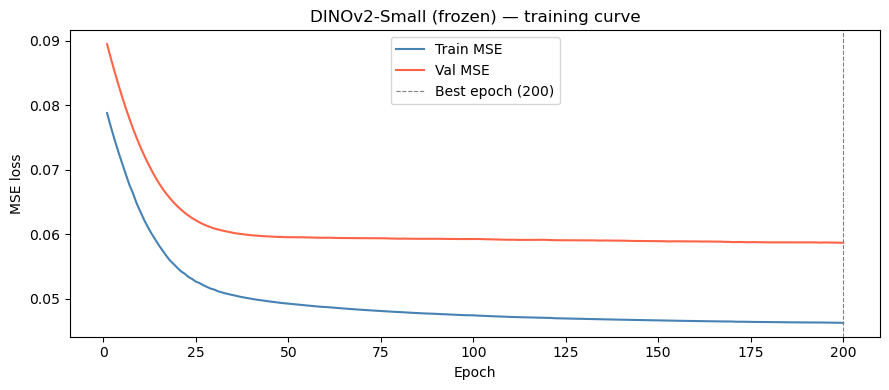

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(train_losses)+1), train_losses, label="Train MSE", color="steelblue")
ax.plot(range(1, len(val_losses)+1),   val_losses,   label="Val MSE",   color="tomato")
ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=0.8,
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title(f"DINOv2-Small (frozen) — training curve")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "nb03_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Optional backbone fine-tuning

Unfreeze the last `N_BLOCKS_UNFREEZE` transformer blocks and train end-to-end at a
very small learning rate (`FINETUNE_LR = 1e-5`). Because this modifies the backbone,
**feature caching is not used** — images are loaded and passed through the full model
at every iteration.

Enable by setting `FINETUNE_BACKBONE = True` in the config cell. Metrics for both
frozen and fine-tuned variants are compared in the table at the end of this section.

In [11]:
if not FINETUNE_BACKBONE:
    print("Fine-tuning skipped (FINETUNE_BACKBONE=False).")
    ft_mae, ft_rmse, ft_r2, ft_spear_r = None, None, None, None
else:
    print(f"Fine-tuning: unfreezing last {N_BLOCKS_UNFREEZE} transformer blocks ...")

    # Re-enable gradients for the last N blocks only
    backbone.train()
    for param in backbone.parameters():
        param.requires_grad = False
    for block in backbone.blocks[-N_BLOCKS_UNFREEZE:]:
        for param in block.parameters():
            param.requires_grad = True
    backbone.to(device)

    n_ft_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
    print(f"  Unfrozen backbone params : {n_ft_params:,}")

    # Load the best frozen-head checkpoint into a fresh head
    ft_head = RegressionHead(FEATURE_DIM, head_type=HEAD_TYPE,
                             hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)
    ft_head.load_state_dict(torch.load(CHECKPOINT, weights_only=True))

    # Two param groups: backbone blocks at small lr, head at normal lr
    ft_optimizer = torch.optim.Adam([
        {"params": [p for b in backbone.blocks[-N_BLOCKS_UNFREEZE:] for p in b.parameters()],
         "lr": FINETUNE_LR},
        {"params": ft_head.parameters(), "lr": LEARNING_RATE},
    ], weight_decay=WEIGHT_DECAY)

    # Image-level datasets (no cached features — backbone changes each step)
    ft_train_ds = IntersectionDataset(train_df, REPRO_ROOT, train_transform, val_transform)
    ft_val_ds   = IntersectionDataset(val_df,   REPRO_ROOT, train_transform, val_transform)
    ft_train_loader = DataLoader(ft_train_ds, batch_size=16, shuffle=True,  num_workers=0)
    ft_val_loader   = DataLoader(ft_val_ds,   batch_size=16, shuffle=False, num_workers=0)

    ft_best_mse   = float("inf")
    ft_patience   = 0
    ft_best_epoch = 0

    for epoch in range(FINETUNE_EPOCHS):
        backbone.train()
        ft_head.train()
        running = 0.0
        for imgs, _, labels in ft_train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            ft_optimizer.zero_grad()
            feats = backbone(imgs)
            if NORMALIZE_FEATURES:
                feats = feats / (feats.norm(dim=1, keepdim=True) + 1e-8)
            loss = criterion(ft_head(feats), labels)
            loss.backward()
            ft_optimizer.step()
            running += loss.item() * len(labels)

        backbone.eval()
        ft_head.eval()
        with torch.no_grad():
            val_run = 0.0
            for imgs, _, labels in ft_val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                feats = backbone(imgs)
                if NORMALIZE_FEATURES:
                    feats = feats / (feats.norm(dim=1, keepdim=True) + 1e-8)
                val_run += criterion(ft_head(feats), labels).item() * len(labels)
        val_mse = val_run / len(ft_val_ds)

        if val_mse < ft_best_mse:
            ft_best_mse   = val_mse
            ft_best_epoch = epoch + 1
            torch.save({"backbone": backbone.state_dict(),
                        "head": ft_head.state_dict()}, FT_CHECKPOINT)
            ft_patience = 0
        else:
            ft_patience += 1

        print(f"FT epoch {epoch+1:3d} | train={running/len(ft_train_ds):.4f} | val={val_mse:.4f}"
              + (" ← best" if ft_patience == 0 else ""))

        if ft_patience >= FINETUNE_PATIENCE:
            print(f"Fine-tuning early stopping at epoch {epoch+1}.")
            break

    # Collect fine-tuned val predictions
    ckpt = torch.load(FT_CHECKPOINT, weights_only=False)
    backbone.load_state_dict(ckpt["backbone"])
    ft_head.load_state_dict(ckpt["head"])
    backbone.eval()
    ft_head.eval()

    ft_preds, ft_labels = [], []
    with torch.no_grad():
        for imgs, _, labels in ft_val_loader:
            feats = backbone(imgs.to(device))
            if NORMALIZE_FEATURES:
                feats = feats / (feats.norm(dim=1, keepdim=True) + 1e-8)
            ft_preds.extend(ft_head(feats).cpu().numpy())
            ft_labels.extend(labels.numpy())

    ft_preds  = np.array(ft_preds)
    ft_labels = np.array(ft_labels)
    ft_mae    = float(np.mean(np.abs(ft_preds - ft_labels)))
    ft_rmse   = float(np.sqrt(np.mean((ft_preds - ft_labels)**2)))
    ft_r2     = float(r2_score(ft_labels, ft_preds))
    ft_spear_r, _ = stats.spearmanr(ft_preds, ft_labels)

    print(f"\nFine-tuned  | MAE={ft_mae:.4f} | RMSE={ft_rmse:.4f} | R²={ft_r2:.4f} | ρ={ft_spear_r:.4f}")

    # Refreeze backbone so downstream cells use the frozen-head checkpoint
    for param in backbone.parameters():
        param.requires_grad = False
    backbone.eval()

Fine-tuning skipped (FINETUNE_BACKBONE=False).


## 6. Validation metrics

Load the best frozen-head checkpoint and compute the four standard metrics.
If fine-tuning was run, a comparison table is appended below.

In [12]:
model.load_state_dict(torch.load(CHECKPOINT, weights_only=True))
model.eval()

all_preds, all_labels, all_ids = [], [], []
with torch.no_grad():
    for feats, labels in val_loader:
        all_preds.extend(model(feats.to(device)).cpu().numpy())
        all_labels.extend(labels.numpy())
all_ids = val_df["intersection_id"].tolist()[:len(all_preds)]

preds_arr  = np.array(all_preds)
labels_arr = np.array(all_labels)

mae      = float(np.mean(np.abs(preds_arr - labels_arr)))
rmse     = float(np.sqrt(np.mean((preds_arr - labels_arr) ** 2)))
r2       = float(r2_score(labels_arr, preds_arr))
spear_r, spear_p = stats.spearmanr(preds_arr, labels_arr)

train_mean = float(train_df["bt_score"].mean())
null_mae   = float(np.mean(np.abs(labels_arr - train_mean)))
null_rmse  = float(np.sqrt(np.mean((labels_arr - train_mean)**2)))

print("=" * 60)
print(f"{'Metric':<22} {'DINOv2 (frozen)':>14} {'Null model':>12}")
print("-" * 60)
print(f"{'MAE':<22} {mae:>14.4f} {null_mae:>12.4f}")
print(f"{'RMSE':<22} {rmse:>14.4f} {null_rmse:>12.4f}")
print(f"{'R²':<22} {r2:>14.4f} {'—':>12}")
print(f"{'Spearman ρ':<22} {spear_r:>14.4f} {'—':>12}")
print(f"{'Spearman p':<22} {spear_p:>14.4f} {'—':>12}")
print("=" * 60)
print(f"Beats null model on MAE: {'YES' if mae < null_mae else 'NO'}")

# Fine-tuning comparison table (only printed when fine-tuning was run)
if FINETUNE_BACKBONE and ft_mae is not None:
    print()
    print("=" * 60)
    print(f"{'Metric':<22} {'Frozen':>14} {'Fine-tuned':>12}")
    print("-" * 60)
    print(f"{'MAE':<22} {mae:>14.4f} {ft_mae:>12.4f}")
    print(f"{'RMSE':<22} {rmse:>14.4f} {ft_rmse:>12.4f}")
    print(f"{'R²':<22} {r2:>14.4f} {ft_r2:>12.4f}")
    print(f"{'Spearman ρ':<22} {spear_r:>14.4f} {ft_spear_r:>12.4f}")
    print("=" * 60)

Metric                 DINOv2 (frozen)   Null model
------------------------------------------------------------
MAE                            0.1924       0.1752
RMSE                           0.2423       0.2347
R²                            -0.0710            —
Spearman ρ                    -0.0147            —
Spearman p                     0.9569            —
Beats null model on MAE: NO


## 7. Attention map visualisation

Extract CLS-to-patch attention from DINOv2's last transformer block for a stratified
sample of val intersections (high-score, mid-score, low-score, high-residual).
The attention map is computed by re-running the QK dot-product inside a forward hook
— this works regardless of whether the model uses FlashAttention.

Spatial regions the model attends to indicate which visual features drive predictions.

In [13]:
def get_cls_attention(backbone, img_tensor, device):
    """Return CLS-to-patch attention averaged over heads (H×W numpy array).

    Uses a forward hook that recomputes the softmax attention weights from Q and K,
    avoiding dependency on whether the model uses FlashAttention internally.
    """
    captured = {}

    def hook(module, inp, _out):
        x = inp[0]  # (1, N, C)
        B, N, C = x.shape
        nh = module.num_heads
        head_dim = C // nh
        # Re-derive Q and K from the QKV projection
        qkv = module.qkv(x).reshape(B, N, 3, nh, head_dim).permute(2, 0, 3, 1, 4)
        q, k = qkv[0], qkv[1]  # (B, nh, N, head_dim)
        scale = head_dim ** -0.5
        attn  = (q @ k.transpose(-2, -1)) * scale  # (B, nh, N, N)
        attn  = attn.softmax(dim=-1)
        # CLS token (index 0) attending to all patches (indices 1:)
        captured["attn"] = attn[0, :, 0, 1:].detach().cpu()  # (nh, n_patches)

    h = backbone.blocks[-1].attn.register_forward_hook(hook)
    backbone.eval()
    with torch.no_grad():
        backbone(img_tensor.unsqueeze(0).to(device))
    h.remove()

    attn_heads = captured["attn"]          # (nh, n_patches)
    attn_mean  = attn_heads.mean(0)        # average over heads
    n_patches  = attn_mean.shape[0]
    patch_grid = int(n_patches ** 0.5)
    return attn_mean.reshape(patch_grid, patch_grid).numpy()


print(f"Attention map shape will be {IMAGE_SIZE//14}×{IMAGE_SIZE//14} patches.")

Attention map shape will be 37×37 patches.


In [14]:
# Select a stratified sample: highest score, lowest score, mid score, highest residual
residuals = preds_arr - labels_arr
val_results = val_df[["intersection_id", "leg_bearing", "bt_score"]].copy()
val_results = val_results.iloc[:len(preds_arr)].copy()
val_results["predicted"]  = preds_arr
val_results["residual"]   = residuals

def pick_examples(df, n=5):
    """Pick a stratified set: high, low, mid actual score + highest absolute residual."""
    sorted_by_score = df.sort_values("bt_score")
    picks = pd.concat([
        sorted_by_score.tail(2),                          # highest scored
        sorted_by_score.head(2),                          # lowest scored
        sorted_by_score.iloc[[len(sorted_by_score)//2]],  # mid scored
        df.loc[[df["residual"].abs().idxmax()]],           # worst prediction
    ]).drop_duplicates("intersection_id").head(n)
    return picks

examples = pick_examples(val_results)
print(f"Selected {len(examples)} intersections for attention visualisation:")
print(examples[["intersection_id", "bt_score", "predicted", "residual"]].to_string(index=False))

Selected 5 intersections for attention visualisation:
 intersection_id  bt_score  predicted  residual
       189267114  0.878489   0.625805 -0.252684
       183264037  0.919890   0.659179 -0.260711
       180271187  0.000000   0.628776  0.628776
       186275130  0.256981   0.670242  0.413262
       186273081  0.773835   0.620446 -0.153389


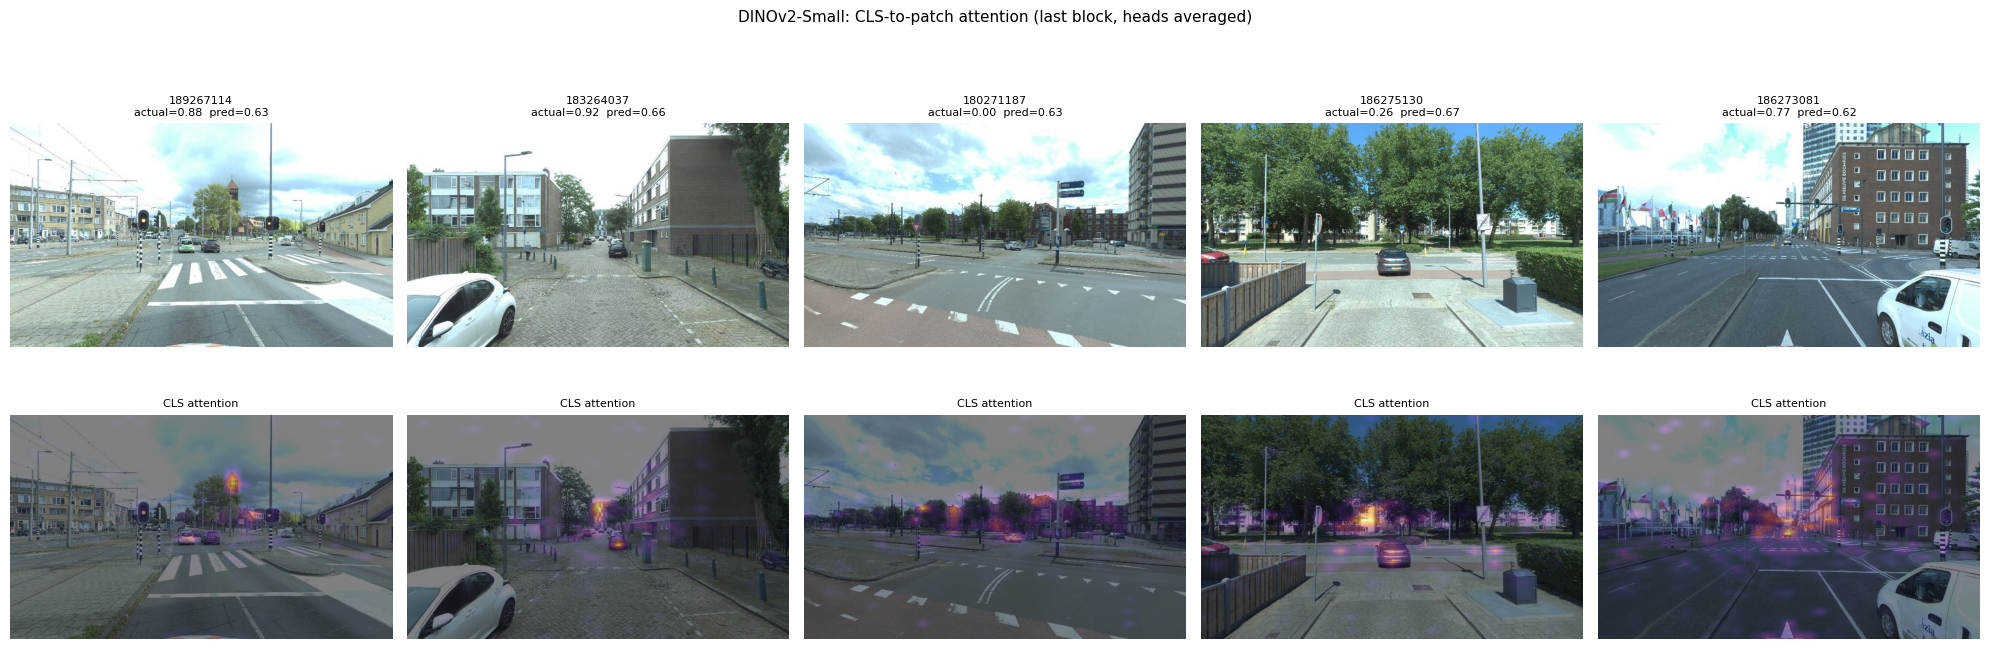

Attention maps saved.


In [15]:
n_examples = len(examples)
fig, axes  = plt.subplots(2, n_examples, figsize=(4 * n_examples, 7))

for col, (_, row) in enumerate(examples.iterrows()):
    iid     = int(row["intersection_id"])
    bearing = float(row["leg_bearing"]) % 360
    path    = REPRO_ROOT / str(iid) / f"leg_{bearing:.0f}.jpeg"

    img_pil = Image.open(path).convert("RGB")

    # --- Top row: original photo ---
    axes[0, col].imshow(img_pil)
    axes[0, col].set_title(
        f"{iid}\nactual={row['bt_score']:.2f}  pred={row['predicted']:.2f}",
        fontsize=8,
    )
    axes[0, col].axis("off")

    # --- Bottom row: attention map overlaid on photo ---
    img_tensor = val_transform(img_pil)  # deterministic transform
    attn_map   = get_cls_attention(backbone, img_tensor, device)  # (37, 37)

    # Upsample attention map to original photo size for overlay
    attn_pil = Image.fromarray(
        (attn_map / attn_map.max() * 255).astype(np.uint8)
    ).resize(img_pil.size, resample=Image.BILINEAR)
    attn_np = np.array(attn_pil)

    axes[1, col].imshow(img_pil)
    axes[1, col].imshow(attn_np, cmap="inferno", alpha=0.5)
    axes[1, col].set_title("CLS attention", fontsize=8)
    axes[1, col].axis("off")

plt.suptitle("DINOv2-Small: CLS-to-patch attention (last block, heads averaged)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "nb03_attention_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Attention maps saved.")

## 8. Residual analysis

Same diagnostic as NB02 — predicted vs actual scatter and residual histogram.
High-error intersections are flagged and compared to the ResNet-50 results.

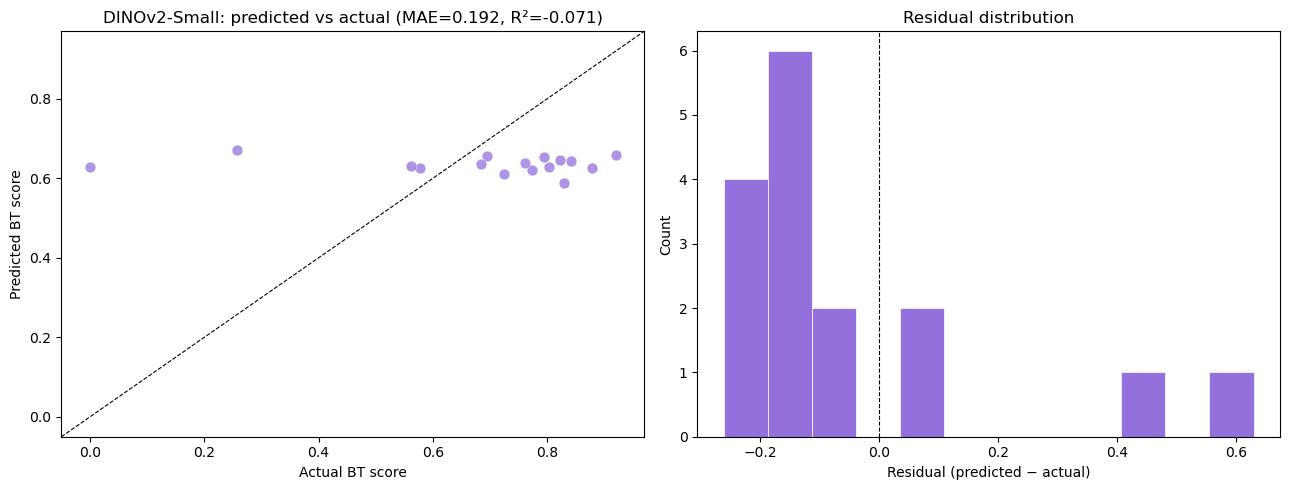

High-error intersections (|residual| > 0.2):
  183264037  pred=0.659  actual=0.920  resid=-0.261  dim_type=T  is_centrum=False
  189267114  pred=0.626  actual=0.878  resid=-0.253  dim_type=4+  is_centrum=False
  187271099  pred=0.588  actual=0.830  resid=-0.243  dim_type=T  is_centrum=False
  186275130  pred=0.670  actual=0.257  resid=+0.413  dim_type=4+  is_centrum=False
  180271187  pred=0.629  actual=0.000  resid=+0.629  dim_type=4+  is_centrum=False


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(labels_arr, preds_arr, alpha=0.75, edgecolors="white", linewidths=0.4,
           color="mediumpurple", s=60)
lims = [min(labels_arr.min(), preds_arr.min()) - 0.05,
        max(labels_arr.max(), preds_arr.max()) + 0.05]
ax.plot(lims, lims, "k--", linewidth=0.8)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual BT score")
ax.set_ylabel("Predicted BT score")
ax.set_title(f"DINOv2-Small: predicted vs actual (MAE={mae:.3f}, R²={r2:.3f})")

ax2 = axes[1]
ax2.hist(residuals, bins=12, color="mediumpurple", edgecolor="white", linewidth=0.5)
ax2.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax2.set_xlabel("Residual (predicted − actual)")
ax2.set_ylabel("Count")
ax2.set_title("Residual distribution")

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "nb03_residual_plot.png", dpi=150, bbox_inches="tight")
plt.show()

ERROR_THRESHOLD = 0.2
high_err = np.abs(residuals) > ERROR_THRESHOLD
if high_err.any():
    print(f"High-error intersections (|residual| > {ERROR_THRESHOLD}):")
    for iid, pred, actual, resid in zip(
        np.array(all_ids)[high_err], preds_arr[high_err],
        labels_arr[high_err], residuals[high_err]
    ):
        r = val_df[val_df["intersection_id"] == iid].iloc[0]
        print(f"  {iid}  pred={pred:.3f}  actual={actual:.3f}  resid={resid:+.3f}  "
              f"dim_type={r.get('dim_type','?')}  is_centrum={r.get('is_centrum','?')}")
else:
    print(f"No intersections with |residual| > {ERROR_THRESHOLD}.")

## 9. Save artefacts

Metrics are saved as JSON for NB04. Fine-tuning results are included if the section
was run.

In [17]:
metrics = {
    "backbone"         : BACKBONE_NAME,
    "n_train"          : len(train_ds),
    "n_val"            : len(val_ds),
    "best_epoch"       : best_epoch,
    "best_val_mse"     : best_val_mse,
    "mae"              : mae,
    "rmse"             : rmse,
    "r2"               : r2,
    "spearman_r"       : float(spear_r),
    "spearman_p"       : float(spear_p),
    "null_mae"         : null_mae,
    "null_rmse"        : null_rmse,
    "train_mean_score" : train_mean,
    "finetuned": {
        "run"       : FINETUNE_BACKBONE,
        "mae"       : ft_mae,
        "rmse"      : ft_rmse,
        "r2"        : ft_r2,
        "spearman_r": float(ft_spear_r) if ft_spear_r is not None else None,
    },
    "experiment_flags": {
        "use_originals_only" : USE_ORIGINALS_ONLY,
        "normalize_features" : NORMALIZE_FEATURES,
        "head_type"          : HEAD_TYPE,
        "weight_decay"       : WEIGHT_DECAY,
        "image_size"         : IMAGE_SIZE,
        "finetune_backbone"  : FINETUNE_BACKBONE,
    },
    "hyperparameters": {
        "feature_dim"   : FEATURE_DIM,
        "hidden_dim"    : HIDDEN_DIM,
        "dropout"       : DROPOUT,
        "learning_rate" : LEARNING_RATE,
        "batch_size"    : BATCH_SIZE,
        "max_epochs"    : MAX_EPOCHS,
        "patience"      : PATIENCE,
    },
}

with open(METRICS_JSON, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved to : {METRICS_JSON}")
print(f"Checkpoint at    : {CHECKPOINT}")

Metrics saved to : ..\outputs\dinov2_vits14_metrics.json
Checkpoint at    : ..\outputs\dinov2_vits14_best.pt


## Summary

| | |
|---|---|
| Backbone | DINOv2-Small (`dinov2_vits14`, patch_size=14) |
| Input size | 518×518 px (37×37 = 1369 patches) |
| Feature dim | 384 |
| Training samples | *[fill from output]* |
| Val samples | *[fill from output]* |
| Best epoch | *[fill from output]* |
| Val MAE | *[fill from output]* |
| Val RMSE | *[fill from output]* |
| R² | *[fill from output]* |
| Spearman ρ | *[fill from output]* |
| Null model MAE | *[fill from output]* |
| Beats null? | *[fill from output]* |
| Fine-tuned (frozen vs FT MAE) | *[fill if run]* |

**Next**: run NB04 to compare ResNet-50 and DINOv2 and select the production model.